Single KNN Accuracy: 0.747
Bagging KNN Accuracy: 0.763

Classification Report (Bagging):
               precision    recall  f1-score   support

           0       0.77      0.75      0.76       148
           1       0.76      0.78      0.77       152

    accuracy                           0.76       300
   macro avg       0.76      0.76      0.76       300
weighted avg       0.76      0.76      0.76       300



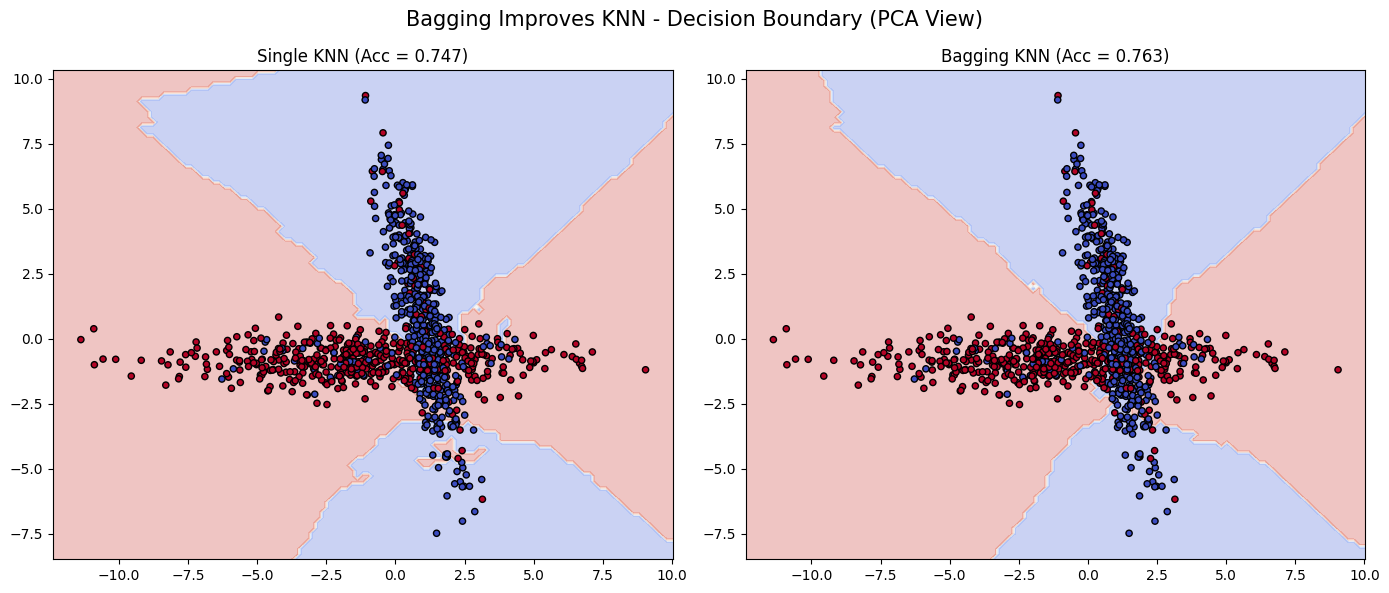

'Output -\nSingle KNN Accuracy: 0.747\nBagging KNN Accuracy: 0.763\nClassification Report (Bagging):\n              precision    recall  f1-score   support\n          0       0.77      0.75      0.76       148\n          1       0.76      0.78      0.77       152\n   accuracy                           0.76       300\n  macro avg       0.76      0.76      0.76       300\nweighted avg       0.76      0.76      0.76       300\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
# 🎯 Generate synthetic dataset (challenging for single KNN)
X, y = make_classification(
   n_samples=1000,
   n_features=20,
   n_informative=2,
   n_redundant=10,
   n_clusters_per_class=1,
   flip_y=0.2,         # Add noise
   class_sep=0.5,      # Low separation
   random_state=42
)
# 🔪 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.3, random_state=42, stratify=y
)
# 🧼 Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X)
# 🌲 Single KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
# 🌲 Bagging KNN
bag_knn = BaggingClassifier(
   estimator=KNeighborsClassifier(n_neighbors=3),
   n_estimators=100,
   max_samples=0.8,
   bootstrap=True,
   n_jobs=-1,
   random_state=42
)
bag_knn.fit(X_train_scaled, y_train)
y_pred_bag = bag_knn.predict(X_test_scaled)
acc_bag = accuracy_score(y_test, y_pred_bag)
# 📊 Print scores
print("Single KNN Accuracy:", round(acc_knn, 3))
print("Bagging KNN Accuracy:", round(acc_bag, 3))
print("\nClassification Report (Bagging):\n", classification_report(y_test, y_pred_bag))
# 🎨 Visualize decision boundaries with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_scaled)
X_test_pca = pca.transform(X_test_scaled)
# Grid for decision surface
h = 0.2
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_original = pca.inverse_transform(grid_pca)
# Predict for plotting
Z_knn = knn.predict(grid_original).reshape(xx.shape)
Z_bag = bag_knn.predict(grid_original).reshape(xx.shape)
# 🖼 Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].contourf(xx, yy, Z_knn, cmap=plt.cm.coolwarm, alpha=0.3)
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
axs[0].set_title(f"Single KNN (Acc = {acc_knn:.3f})")
axs[1].contourf(xx, yy, Z_bag, cmap=plt.cm.coolwarm, alpha=0.3)
axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
axs[1].set_title(f"Bagging KNN (Acc = {acc_bag:.3f})")
plt.suptitle("Bagging Improves KNN - Decision Boundary (PCA View)", fontsize=15)
plt.tight_layout()
plt.show()
'''Output -
Single KNN Accuracy: 0.747
Bagging KNN Accuracy: 0.763
Classification Report (Bagging):
              precision    recall  f1-score   support
          0       0.77      0.75      0.76       148
          1       0.76      0.78      0.77       152
   accuracy                           0.76       300
  macro avg       0.76      0.76      0.76       300
weighted avg       0.76      0.76      0.76       300
'''